In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import re


In [2]:
df=pd.read_csv('sentiment analysis/sentiment_analysis.csv')
df=df[['sentiment','text']]
# select column 
print(df.head())
print("-" * 50)
print(df.shape)
print("-" * 50)
print(df.isnull().sum())
print("-" * 50)
print(df['sentiment'].value_counts())

  sentiment                                               text
0  positive              What a great day!!! Looks like dream.
1  positive     I feel sorry, I miss you here in the sea beach
2  negative                                     Don't angry me
3  negative  We attend in the class just for listening teac...
4  negative                  Those who want to go, let them go
--------------------------------------------------
(499, 2)
--------------------------------------------------
sentiment    0
text         0
dtype: int64
--------------------------------------------------
sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64


Text(0, 0.5, '')

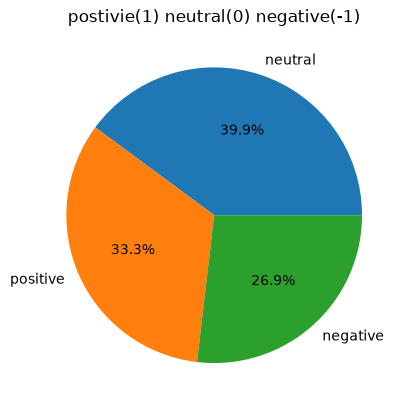

In [3]:
ax=df['sentiment'].value_counts().plot.pie( autopct='%1.1f%%',  shadow=False) 
# autopct: automatically calculate and display the percentage value %:start the format 1:placeholder ensuring it takes up the space needed .1:one digit after decimal f:float %%:escape a literal percentage sign
ax.set_title('postivie(1) neutral(0) negative(-1)') 
ax.set_ylabel('') 

In [4]:
sentiment_mapping={'positive':1,'neutral':0,'negative':-1}
df['sentiment']=df['sentiment'].map(sentiment_mapping)
# for t in range(-1,2):
for t in sorted(df['sentiment'].unique()):
# include start exclude the end 
    print(f"---sentiment {t}---")
    # print(df[df["sentiment"]==t]["sentiment"].value_counts())
    print(len(df[df['sentiment']==t]))

---sentiment -1---
134
---sentiment 0---
199
---sentiment 1---
166


In [5]:
# three easy way to see the sorted count
print(df['sentiment'].value_counts())
print(df['sentiment'].value_counts().sort_index)
print(df.groupby('sentiment').size())

sentiment
 0    199
 1    166
-1    134
Name: count, dtype: int64
<bound method Series.sort_index of sentiment
 0    199
 1    166
-1    134
Name: count, dtype: int64>
sentiment
-1    134
 0    199
 1    166
dtype: int64


In [6]:
df.head()

,sentiment,text
0,1,What a great day!!! Looks like dream.
1,1,"I feel sorry, I miss you here in the sea beach"
2,-1,Don't angry me
3,-1,We attend in the class just for listening teac...
4,-1,"Those who want to go, let them go"


In [7]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))
negations={'not','no','never','nor'}
lemmatizer=WordNetLemmatizer()
def lemma(w):
    return lemmatizer.lemmatize(lemmatizer.lemmatize(w,pos='v'),pos='n')
# find the stem of the word: grabbing-> grab,default noun only-->concat first verb then noun 
def clean_text(text):
# convert all text to lowercase 
# not clean enough
# Remove punctuation ("day!!!" stays as "day!!!")
# Remove stopwords ("the", "is", "a" — which carry no sentiment)
# Remove numbers, URLs, HTML tags
# Handle contractions ("don't" → "do not" or just "dont")
# Lemmatize/stem ("listening" → "listen", "going" → "go")
    if not isinstance(text,str):
        return []
    text=text.lower()
    text=re.sub(r'http\S+|www\S+',' ',text)
    text=re.sub(r'<.*?>',' ',text)
    # order is important
    text=re.sub(r"[`’]","'",text)
    # re.sub() uses regular expression patterns for flexible pattern matching, whereas str.replace() performs fast, exact literal substring replacements.
    text=text.replace("n't"," not")
    # text=re.sub(r"n't\b", " not", text)
    # \b means a word boundary->It ensures that n't is only matched if it is at the end of a complete word.
    text=re.sub(r'[^a-z\s]',' ',text)
    # ^:negate a-z\s:any lowercase letter and white space 
    # only space and letter kept 
    text=re.sub(r'\s+',' ',text).strip()
    # strip()remove extra space that sit at the begining and the end
    # re.sub(r'\s+', ' ', text) collapse repeated space 
    tokens=text.split()
    # column of word list 
    tokens=[lemma(w) for w in tokens
            if (w not in stop_words and len(w)>2) or w in negations]
    return ' '.join(tokens)
    # return string 

df['clean_text']=df['text'].apply(clean_text)
df=df[df['clean_text']!='']
df.head()

,sentiment,text,clean_text
0,1,What a great day!!! Looks like dream.,great day look like dream
1,1,"I feel sorry, I miss you here in the sea beach",feel sorry miss sea beach
2,-1,Don't angry me,not angry
3,-1,We attend in the class just for listening teac...,attend class listen teacher read slide nonsence
4,-1,"Those who want to go, let them go",want let


In [8]:
df.tail()

,sentiment,text,clean_text
494,-1,"According to , a quarter of families under six...",accord quarter family six live poverty
495,-1,the plan to not spend money is not going well,plan not spend money not go well
496,0,uploading all my bamboozle pictures of facebook,upload bamboozle picture facebook
497,1,congratulations ! you guys finish a month ear...,congratulation guy finish month early booo
498,-1,"actually, I wish I was back in Tahoe. I miss...",actually wish back tahoe miss


In [9]:
from collections import Counter
all_words=' '.join(df['clean_text']).split()
# always remember to have ' 'space in between, otherwise the last word of one row will stick with first word next row
counts=Counter(all_words)
print(counts.most_common(10))
print(counts.most_common()[:-11:-1])

[('not', 74), ('day', 55), ('get', 42), ('go', 40), ('love', 34), ('know', 31), ('like', 30), ('happy', 24), ('today', 23), ('really', 22)]
[('tahoe', 1), ('month', 1), ('guy', 1), ('bamboozle', 1), ('money', 1), ('poverty', 1), ('six', 1), ('quarter', 1), ('accord', 1), ('proud', 1)]


In [10]:
x_train,x_test,y_train,y_test=train_test_split(df['clean_text'],df['sentiment'],test_size=0.2,random_state=42)
print("Train size", len(x_train))
print("Test size", len(x_test))

Train size 396
Test size 100


In [11]:
num_folds=5
from sklearn.model_selection import StratifiedKFold
skf=StratifiedKFold(n_splits=num_folds,shuffle=True,random_state=42)
for fold,(train_index,test_index) in enumerate(skf.split(df['clean_text'],df['sentiment'])):
    print(f"Fold {fold+1}")
    print("Train size", len(train_index))
    print("Test size", len(test_index))
    print("-"*50)  

Fold 1
Train size 396
Test size 100
--------------------------------------------------
Fold 2
Train size 397
Test size 99
--------------------------------------------------
Fold 3
Train size 397
Test size 99
--------------------------------------------------
Fold 4
Train size 397
Test size 99
--------------------------------------------------
Fold 5
Train size 397
Test size 99
--------------------------------------------------


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer=TfidfVectorizer(max_features=1000,ngram_range=(1,2),min_df=2,sublinear_tf=True)
# TfidfVectorizer lowercases and drops punctuation and one-letter tokens by default
# IDF already shrinks the weight of very common words like the and to
# so using TfidfVectorizer can shrink the clean_text function 
# min_df:If a word appears in fewer than min_df documents, it's dropped from the vocabulary entirely.  prevent from vocabulary bloat and overfitting
# sublinear_tf=True, it replaces tf with 1 + log(tf): compressed growth for a word appears many times in one document:A word appearing 10× isn't 10× more important than a word appearing once — it's more like 3×. sublinear_tf caps the inflation from repetition. especially In sentiment analysis, opinion-heavy texts often repeat emotional words ("love love love", "so so good"). Sublinear TF prevents repetition from skewing the score.



# max_features is not the bigger the better--> easily cause overfitting-model memorize training data->poor generalization: new documents do not share the exact tokens seen in training.
# tokenize on whitespace
# TF-IDF vectorizer: convert raw text to numerical matrix
# TF:term frequency: how ofen a feature apprear in a document 
# IDF:inverse document frequency:how rare a word is across the entire corpus
# TF-IDF=TF × IDF	High if the word is frequent in this doc but rare elsewhere
# t=term=feature=column=word
# d=document=each row
# D=dataset
# max_feature: the maximun term kept
# ngram_range: unigram: one term/token:good;not bigram: two term/token :not good
x_train_tfidf=vectorizer.fit_transform(x_train)
# learn+apply
x_test_tfidf=vectorizer.transform(x_test)
# apply
print("tf-idf shape train",x_train_tfidf.shape)
print("tf-idf shape test",x_test_tfidf.shape)

tf-idf shape train (396, 801)
tf-idf shape test (100, 801)


In [13]:
# vectorizercount=CountVectorizer(max_features=5000,ngram_range=(1,2))
# x_train_c=vectorizercount.fit_transform(x_train)
# # learn+apply
# x_test_c=vectorizercount.transform(x_test)
# # apply
# print("c shape train",x_train_c.shape)
# print("c shape test",x_test_c.shape)

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score, classification_report
# bernoulli naive bayes ignore word frequency: bernoulli:binary
# gaussian naive bayes: continuos--> Gaussian distribution
# multinomial naive bayes: learns from training data by analyzing how often words occur in each class
model_NB=MultinomialNB()
model_NB.fit(x_train_tfidf,y_train)
y_pred=model_NB.predict(x_test_tfidf)
# evaluates a logical equivalence between the two arrays
accuracy=accuracy_score(y_test,y_pred)
# three class random 33.33%
print(f"Accuracy: {accuracy*100:.2f}%\n")
# defualt average='binary'--> only for 2 classes, for multiclass, pass average='macro'/'weighted'/'micro'/None 
precision = precision_score(y_test, y_pred, average='macro')
# macro means unweighted: (0.88+0.47+0.79)/3 -->used for balanced :every class matters equally
recall    = recall_score(y_test, y_pred, average='weighted')
# average='weighted' 36*0.88+30*0.47+34*0.79/100 --> used for imbalanced : bigger class matter more 
f1        = f1_score(y_test, y_pred, average=None)
# average='micro': same as accuracy
# average=None: a array for each class 
print(f"Precision: {precision*100:.2f}%\n")
print(f"Recall: {recall*100:.2f}%\n")
print(f"F1: {f1}")
# classification_report combine f1/recall/precision/accuracy and number of data(support)
print(classification_report(y_test,y_pred))
# red flag for the classification_report
# One class has very high recall but low precision->	Model over-predicts that class
# One class has very low support (e.g., 3 samples)->	Metrics for that class are unreliable
# Accuracy >> macro F1->	Model is biased toward majority class
# All F1 scores are near 0.33->	Model is basically guessing


# without cleaning
# Accuracy: 61.00%

# Precision: 71.11%

# Recall: 61.00%

# F1: [0.53846154 0.62222222 0.65517241]
#               precision    recall  f1-score   support

#           -1       0.88      0.39      0.54        36
#            0       0.47      0.93      0.62        30
#            1       0.79      0.56      0.66        34

#     accuracy                           0.61       100
#    macro avg       0.71      0.63      0.61       100
# weighted avg       0.72      0.61      0.60       100


# with punctuation

# Accuracy: 58.00%

# Precision: 64.03%

# Recall: 58.00%

# F1: [0.46808511 0.59183673 0.65454545]
#               precision    recall  f1-score   support

#           -1       0.69      0.35      0.47        31
#            0       0.48      0.76      0.59        38
#            1       0.75      0.58      0.65        31

#     accuracy                           0.58       100
#    macro avg       0.64      0.57      0.57       100
# weighted avg       0.63      0.58      0.57       100




Accuracy: 68.00%

Precision: 72.68%

Recall: 68.00%

F1: [0.69387755 0.67391304 0.6779661 ]
              precision    recall  f1-score   support

          -1       0.89      0.57      0.69        30
           0       0.60      0.78      0.67        40
           1       0.69      0.67      0.68        30

    accuracy                           0.68       100
   macro avg       0.73      0.67      0.68       100
weighted avg       0.71      0.68      0.68       100



In [15]:
from sklearn.svm import SVC
svm_model=SVC(kernel='linear',C=1.0,decision_function_shape='ovr')
svm_model.fit(x_train_tfidf,y_train)
y_pred_svm=svm_model.predict(x_test_tfidf)
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

          -1       0.72      0.60      0.65        30
           0       0.56      0.62      0.59        40
           1       0.63      0.63      0.63        30

    accuracy                           0.62       100
   macro avg       0.64      0.62      0.63       100
weighted avg       0.63      0.62      0.62       100



In [16]:
from sklearn import linear_model
logistic_model=linear_model.LogisticRegression(max_iter=1000)
logistic_model.fit(x_train_tfidf,y_train)
y_pred_logistic=logistic_model.predict(x_test_tfidf)
print(classification_report(y_test,y_pred_logistic))

              precision    recall  f1-score   support

          -1       0.70      0.53      0.60        30
           0       0.56      0.68      0.61        40
           1       0.66      0.63      0.64        30

    accuracy                           0.62       100
   macro avg       0.64      0.61      0.62       100
weighted avg       0.63      0.62      0.62       100



In [17]:
custom_message=["I love this!", "I hate that!", "It was okay, not great."]
for msg in custom_message:
    custom_vector=vectorizer.transform([msg])
    prediction_NB=model_NB.predict(custom_vector)[0]
    # [0] return the first element of the array, which is the predicted sentiment label for the input message. The predicted sentiment label is then used to look up the corresponding sentiment string in the sentiment_mapping dictionary, which maps sentiment labels to their corresponding string representations. The resulting string is then printed to the console along with the original message and the predicted sentiment label.
    # if compare array with a single value, it will throw an error, so we need to use [0] to get the first element of the array.
    sentiment_label= "postive" if prediction_NB==1 else "Neutral" if prediction_NB==0 else "Negative"
    print(f"NB: {msg} --> {sentiment_label}")
    prediction_SVM=svm_model.predict(custom_vector)[0]
    sentiment_label= "postive" if prediction_SVM==1 else "Neutral" if prediction_SVM==0 else "Negative"
    print(f"SVM: {msg} --> {sentiment_label}")
    prediction_Logistic=logistic_model.predict(custom_vector)[0]
    sentiment_label= "postive" if prediction_Logistic==1 else "Neutral" if prediction_Logistic==0 else "Negative"
    print(f"Logistic: {msg} --> {sentiment_label}")
    print("-" * 50)

NB: I love this! --> postive
SVM: I love this! --> postive
Logistic: I love this! --> postive
--------------------------------------------------
NB: I hate that! --> Negative
SVM: I hate that! --> Negative
Logistic: I hate that! --> Negative
--------------------------------------------------
NB: It was okay, not great. --> Neutral
SVM: It was okay, not great. --> postive
Logistic: It was okay, not great. --> Negative
--------------------------------------------------


In [18]:
# accuracy and standard deviation of the models and inputs using cross-validation
models={
    'NB': MultinomialNB(),
    'LogReg':linear_model.LogisticRegression(max_iter=1000),
    'SVC':SVC(kernel='linear',C=1.0,decision_function_shape='ovr'),
}

input_text={
    'lowercase only': df['text'].str.lower(),
    'cleaned text': df['text'].apply(clean_text),
}
inputdf=pd.DataFrame(input_text)
# Table-Like Dictionaries Need Equal Sizes, they are two columns side by side. 
# pd.DataFrame({ 'ColA': [...], 'ColB': [...] })->Columns (side-by-side). Keys are headers.
# pd.DataFrame([ {row1}, {row2} ])->Rows (stacked). Each dictionary is a row.

for iname, x in input_text.items():
    print(f"input_text: {iname}")
    x_train,x_test,y_train,y_test=train_test_split(x,df['sentiment'],test_size=0.2,random_state=42)
    x_train_tfidf=vectorizer.fit_transform(x_train)
    x_test_tfidf=vectorizer.transform(x_test)
    for mname, model in models.items():
        model.fit(x_train_tfidf,y_train)
        y_pred=model.predict(x_test_tfidf)
        accuracy=accuracy_score(y_test,y_pred)
        print(f"Model: {mname}, Accuracy: {accuracy*100:.2f}%")
    print("-"*50)

inputdf.tail()

input_text: lowercase only
Model: NB, Accuracy: 55.00%
Model: LogReg, Accuracy: 61.00%
Model: SVC, Accuracy: 58.00%
--------------------------------------------------
input_text: cleaned text
Model: NB, Accuracy: 68.00%
Model: LogReg, Accuracy: 62.00%
Model: SVC, Accuracy: 62.00%
--------------------------------------------------


,lowercase only,cleaned text
494,"according to , a quarter of families under six...",accord quarter family six live poverty
495,the plan to not spend money is not going well,plan not spend money not go well
496,uploading all my bamboozle pictures of facebook,upload bamboozle picture facebook
497,congratulations ! you guys finish a month ear...,congratulation guy finish month early booo
498,"actually, i wish i was back in tahoe. i miss...",actually wish back tahoe miss


In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
for iname, x in input_text.items():
    for mname, model in models.items():
        pipe=make_pipeline(TfidfVectorizer(ngram_range=(1,2)), model)
        score=cross_val_score(pipe, x, df['sentiment'], cv=num_folds, scoring='accuracy')
        print(f"Input: {iname}, Model: {mname}, Accuracy: {score.mean()*100:.2f}% (+/- {score.std() * 2 * 100:.2f}%)")
        print("-"*50)

# If the gaps are smaller than the ±, then cleaning made no measurable difference on this data

Input: lowercase only, Model: NB, Accuracy: 63.72% (+/- 31.85%)
--------------------------------------------------
Input: lowercase only, Model: LogReg, Accuracy: 65.54% (+/- 30.80%)
--------------------------------------------------
Input: lowercase only, Model: SVC, Accuracy: 68.36% (+/- 27.79%)
--------------------------------------------------
Input: cleaned text, Model: NB, Accuracy: 67.95% (+/- 28.97%)
--------------------------------------------------
Input: cleaned text, Model: LogReg, Accuracy: 67.36% (+/- 32.28%)
--------------------------------------------------
Input: cleaned text, Model: SVC, Accuracy: 68.98% (+/- 30.83%)
--------------------------------------------------
